In [75]:
import pandas as pd
from matplotlib import pyplot as plt

fp = "/playpen/mufan/levi/tianlong-chen-lab/material-super-resolution/__exps__/p(z | X)/ablation-model-variant/2024-11-29_11-46-15_vit_l_16_replace_all_heads/results.csv"
df = pd.read_csv(fp)
df.head()

,global_train_step,global_val_step,epoch,train_loss,val_loss,z
0,0.0,NaN,0,0.081337,NaN,0.073965
1,1.0,NaN,0,0.002357,NaN,0.040606
2,2.0,NaN,0,0.006916,NaN,0.056354
3,3.0,NaN,0,0.001050,NaN,0.019288
4,4.0,NaN,0,0.011522,NaN,0.087651


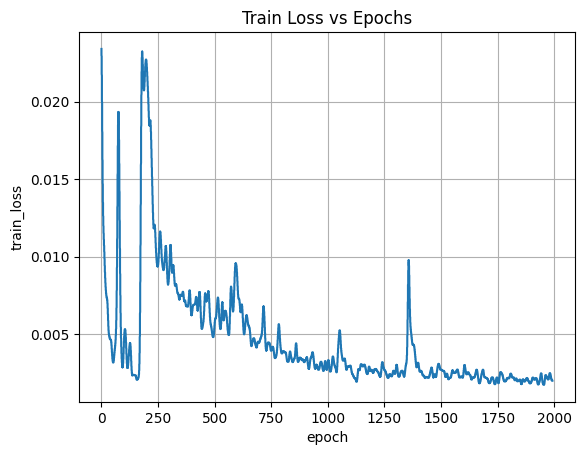

In [76]:
from scipy.ndimage import gaussian_filter1d

SIGMA = 50

_df = df[df["global_train_step"].notna()]
train_steps = _df["epoch"]
train_losses = _df["train_loss"]
train_losses_smoothed = gaussian_filter1d(train_losses, sigma=SIGMA)

# plt.plot(train_steps, train_losses)
plt.plot(train_steps, train_losses_smoothed)
plt.xlabel("epoch")
plt.ylabel("train_loss")
plt.title("Train Loss vs Epochs")
plt.grid()
plt.show()

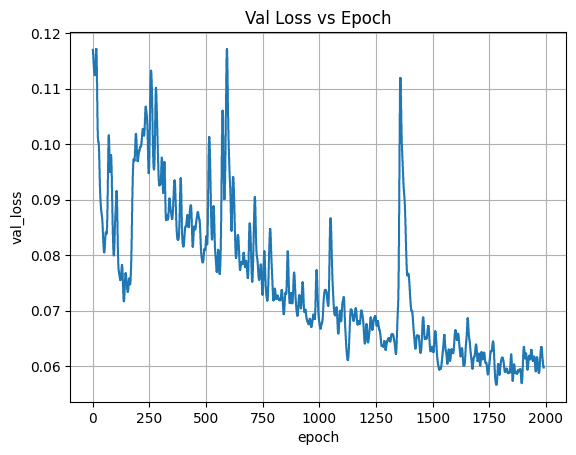

In [77]:
# plot val_loss vs. global_val_step
_df = df[df["global_val_step"].notna()]
val_steps = _df["epoch"]
val_losses = _df["val_loss"]
val_losses_smoothed = gaussian_filter1d(val_losses, sigma=SIGMA)

# plt.plot(val_steps, val_losses)
plt.plot(val_steps, val_losses_smoothed)
plt.xlabel("epoch")
plt.ylabel("val_loss")
plt.title("Val Loss vs Epoch")
plt.grid()
plt.show()

In [78]:
import numpy as np

np.mean(train_losses[-1000: ]) * 100, np.mean(val_losses[-1000: -500]) * 100

(0.21269222898117227, 6.096740675717588)

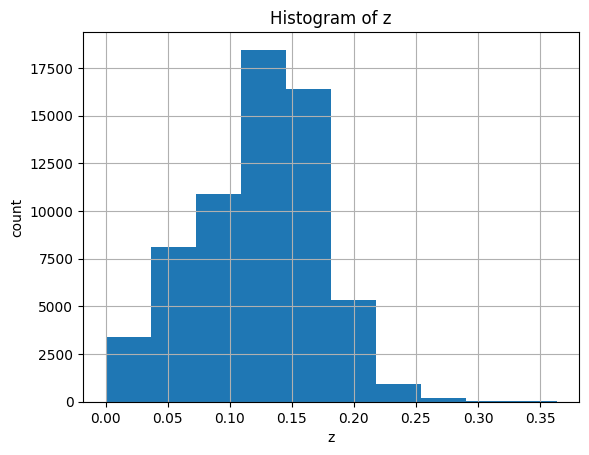

mean: 0.1233286197297154
std: 0.04943652703014935


In [79]:
zs = df['z']

# plot a histogram of z
plt.hist(zs)
plt.xlabel("z")
plt.ylabel("count")
plt.title("Histogram of z")
plt.grid()
plt.show()

# show on figure mean and std of zs
print(f"mean: {zs.mean()}")
print(f"std: {zs.std()}")

In [80]:
import math

# Given mean and standard deviation
mean = zs.mean()
std_dev = zs.std()

# Calculate MAE using the formula for a normal distribution
mae = std_dev * math.sqrt(2 / math.pi)

print(f"MAE of always predicting the mean: {mae:.6f}")

MAE of always predicting the mean: 0.039445
